In [1]:
import infercnvpy as cnv

import scanpy as sc
import pandas as pd
import infercnvpy as cnv
import numpy as np 

import sys
import os
sys.path.append("/home/augusta/storage3/augusta/insituCNV/InSituCNV")
import insitucnv as icv

import spatialdata as sd
from spatialdata_io import xenium
import spatialdata_plot

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
sc.settings.verbosity = 3   # 0: error, 1: warn, 2: info, 3: hint
import squidpy as sq

/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set default figure size globally for matplotlib (width, height in inches)
plt.rcParams['figure.figsize'] = (16, 16)  # Adjust as needed

# Load the data

In [3]:
adata = sc.read_h5ad("//home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/data/1105_BL.h5ad")

In [4]:
adata

AnnData object with n_obs × n_vars = 19413 × 5099
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'leiden', 'cell.id', 'cell_type_oct25', 'compartment'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'cell_type_oct25_colors', 'compartment_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'log_norm', 'raw_counts'
    obsp: 'con

# CNV inference across lognorm, MAGIC, and smooth layers


In [5]:
# Layer prep: log-normalized, MAGIC, and insitucnv smoothing
import magic

# Ensure raw counts exist in layers
if 'raw_counts' not in adata.layers:
    adata.layers['raw_counts'] = adata.X.copy()

# Create log-normalized and MAGIC layers
adata.X = adata.layers['raw_counts'].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers['log_norm'] = adata.X.copy()

# MAGIC on log-normalized data
magic_op = magic.MAGIC(t=1, knn=20, random_state=0)
adata_magic = magic_op.fit_transform(adata)
adata.layers['magic'] = adata_magic.X

# Create insitucnv-smoothed layer
adata.X = adata.layers['raw_counts'].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
adata.layers['raw'] = adata.X.copy()
sc.pp.neighbors(adata, n_neighbors=20)
icv.tl.smooth_data_for_cnv(adata, layer_w_norm_counts='raw', n_neighbors=20)

adata.X = adata.layers['M'].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers['smooth'] = adata.X.copy()


normalizing counts per cell
    finished (0:00:00)
Calculating MAGIC...
  Running MAGIC on 19413 cells and 5099 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 3.85 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.70 seconds.
    Calculating affinities...
    Calculated affinities in 2.29 seconds.
  Calculated graph and diffusion operator in 6.95 seconds.
  Calculating imputation...
  Calculated imputation in 7.46 seconds.
Calculated MAGIC in 14.60 seconds.
normalizing counts per cell
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:24)
normalizing counts per cell
    finished (0:00:00)


## Add genomic positions


In [6]:
adata = icv.pp.add_genomic_positions(adata)

Added genomic positions and ids to 5090 genes, out of 5099 genes in total!


## Run inferCNV per layer and store results


In [7]:
reference_key = 'cell_type_oct25'
reference_cat = ["T_cells", "B_cells", "Myeloid", "Plasma","Fibroblast", "Endothelial", "Adipocytes", "PVLs"]

In [8]:
from matplotlib import cm
from matplotlib.colors import to_hex

METHODS = ['log_norm', 'magic', 'smooth']


def run_cnv_for_layer(ad, method, reference_key=reference_key, reference_cat=reference_cat):
    # Switch to the requested layer
    ad.X = ad.layers[method].copy()

    # inferCNV
    cnv.tl.infercnv(
        ad,
        window_size=60,
        step=10,
        lfc_clip=4,
        reference_key=reference_key,
        reference_cat=reference_cat,
        chunksize=1000,
        calculate_gene_values=True,
    )

    # Cache gene-level CNV layer under a method-specific name
    if 'gene_values_cnv' in ad.layers:
        ad.layers[f'gene_values_cnv_{method}'] = ad.layers['gene_values_cnv'].copy()

    # CNV-based PCA + neighbors
    cnv.tl.pca(ad)
    cnv.pp.neighbors(ad)

    # Leiden clustering (default resolution)
    leiden_key = f'cnv_leiden_{method}'
    cnv.tl.leiden(ad, key_added=leiden_key)

    # Refresh colors for the new clustering key
    color_key = f'{leiden_key}_colors'
    if color_key in ad.uns:
        del ad.uns[color_key]
    n = ad.obs[leiden_key].nunique()
    ad.uns[color_key] = [to_hex(cm.tab20(i / n)) for i in range(n)]


for m in METHODS:
    run_cnv_for_layer(adata, m)


100%|██████████| 20/20 [01:05<00:00,  3.29s/it]


computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    finished: added to `.uns['cnv_neighbors']`
    `.obsp['cnv_neighbors_distances']`, distances for each pair of neighbors
    `.obsp['cnv_neighbors_connectivities']`, weighted adjacency matrix (0:00:03)
running Leiden clustering
    finished: found 23 clusters and added
    'cnv_leiden_log_norm', the cluster labels (adata.obs, categorical) (0:00:16)


100%|██████████| 20/20 [01:06<00:00,  3.35s/it]


computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    finished: added to `.uns['cnv_neighbors']`
    `.obsp['cnv_neighbors_distances']`, distances for each pair of neighbors
    `.obsp['cnv_neighbors_connectivities']`, weighted adjacency matrix (0:00:03)
running Leiden clustering
    finished: found 44 clusters and added
    'cnv_leiden_magic', the cluster labels (adata.obs, categorical) (0:00:07)


100%|██████████| 20/20 [01:09<00:00,  3.49s/it]


computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    finished: added to `.uns['cnv_neighbors']`
    `.obsp['cnv_neighbors_distances']`, distances for each pair of neighbors
    `.obsp['cnv_neighbors_connectivities']`, weighted adjacency matrix (0:00:03)
running Leiden clustering
    finished: found 21 clusters and added
    'cnv_leiden_smooth', the cluster labels (adata.obs, categorical) (0:00:15)


## Side-by-side CNV heatmaps (lognorm, MAGIC, smooth)


computing PCA
    with n_comps=50
    finished (0:00:00)
Storing dendrogram info using `.uns['dendrogram_cnv_leiden_log_norm']`
categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


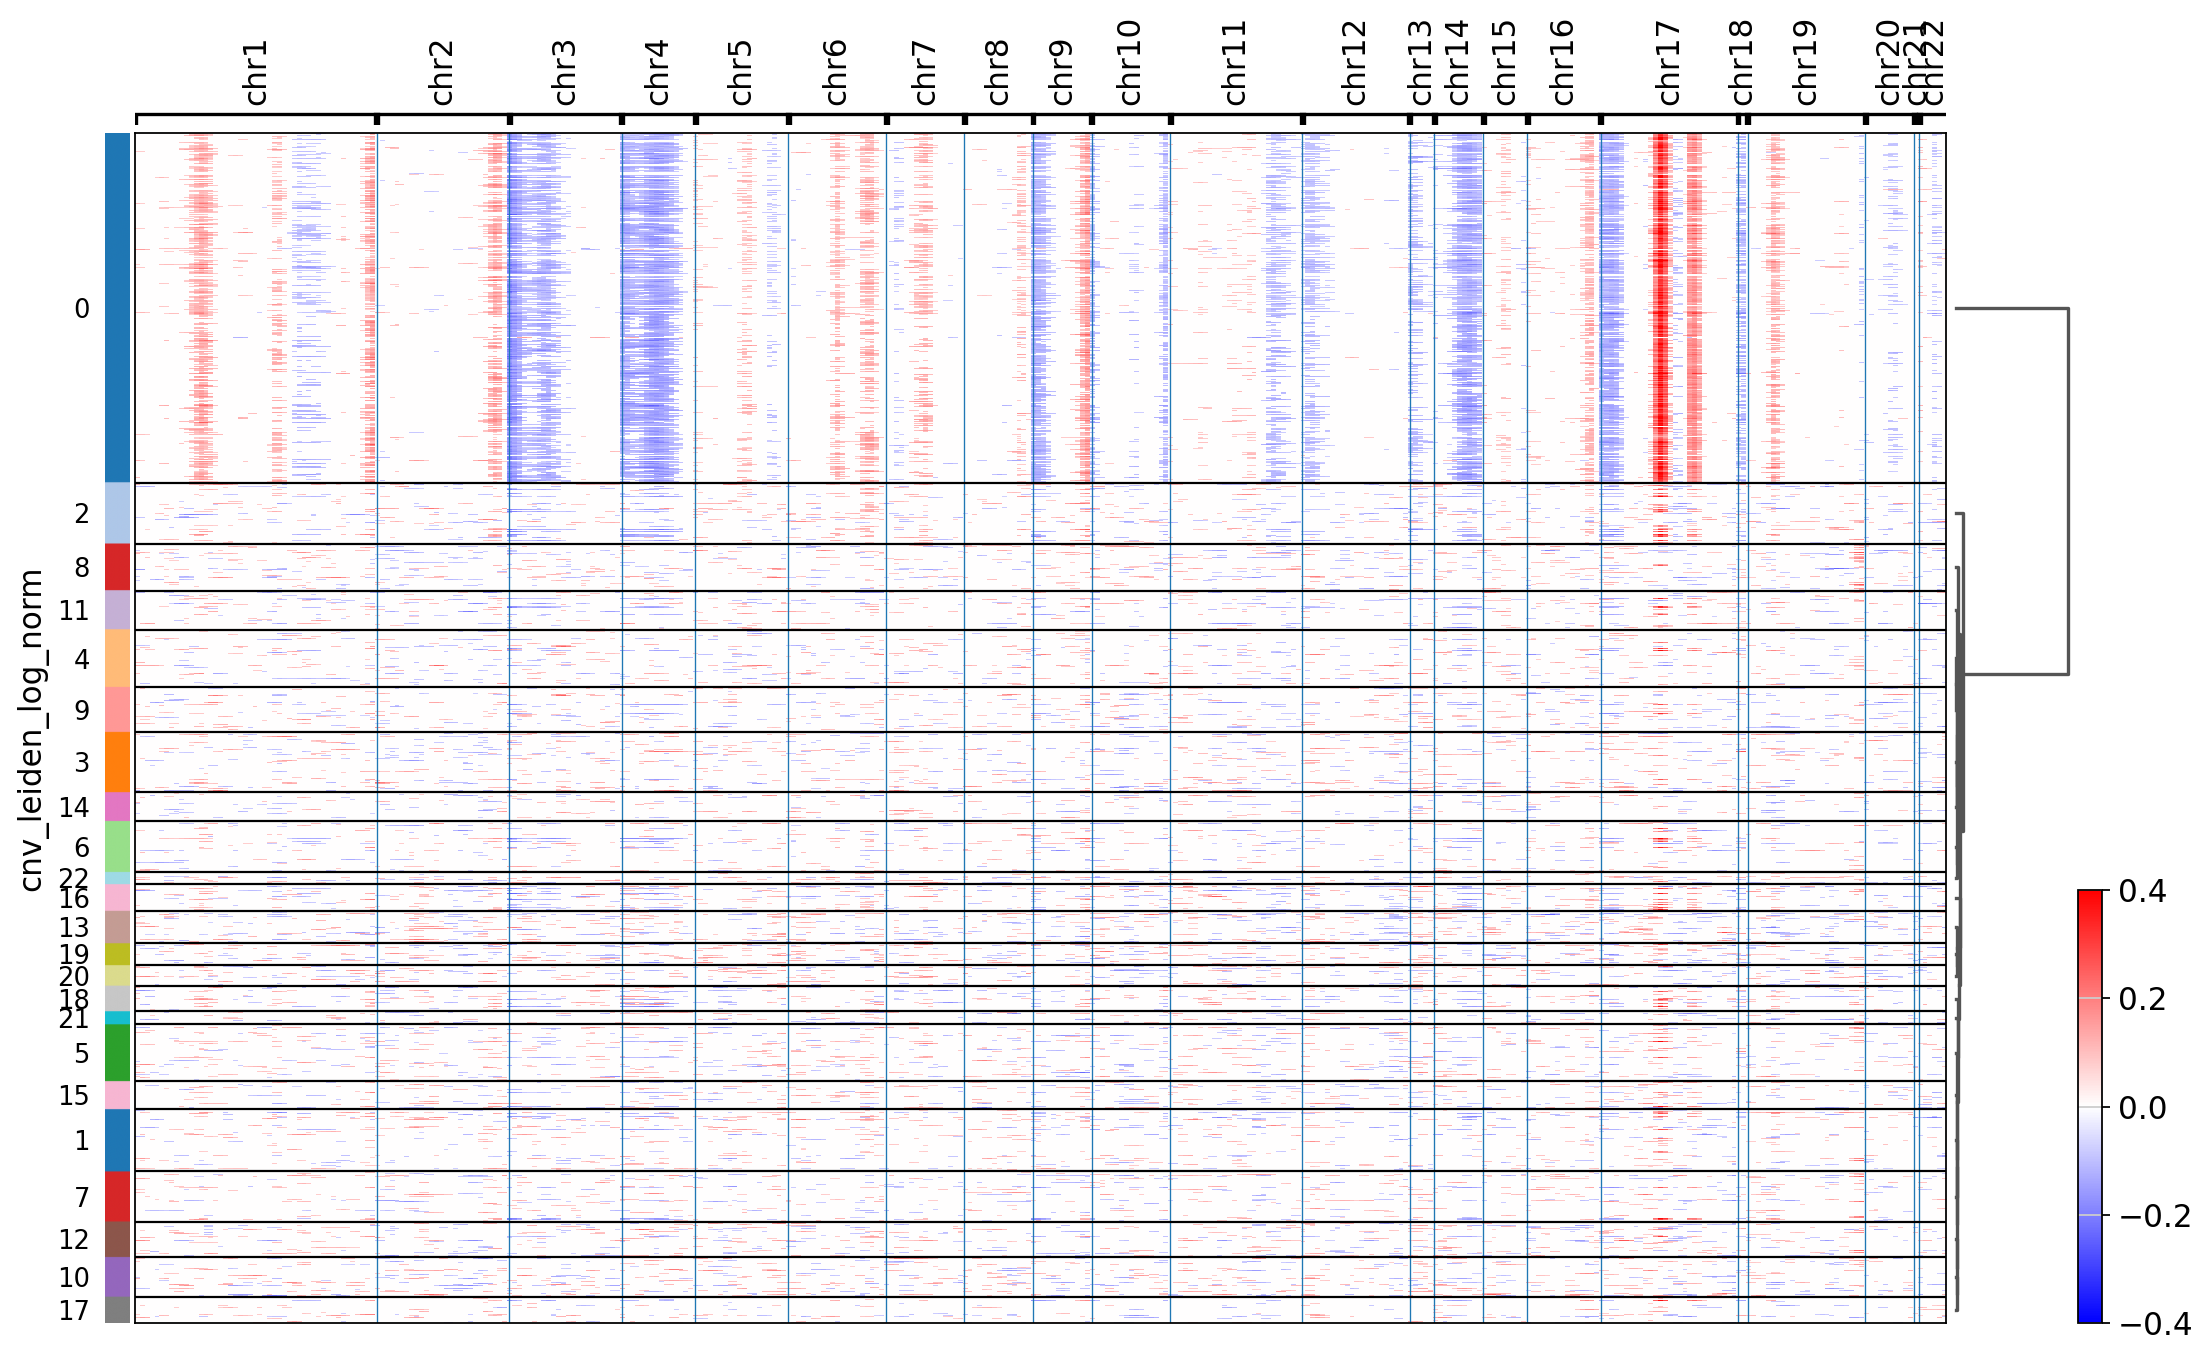

computing PCA
    with n_comps=50
    finished (0:00:00)
Storing dendrogram info using `.uns['dendrogram_cnv_leiden_magic']`
categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


<Figure size 1280x1280 with 0 Axes>

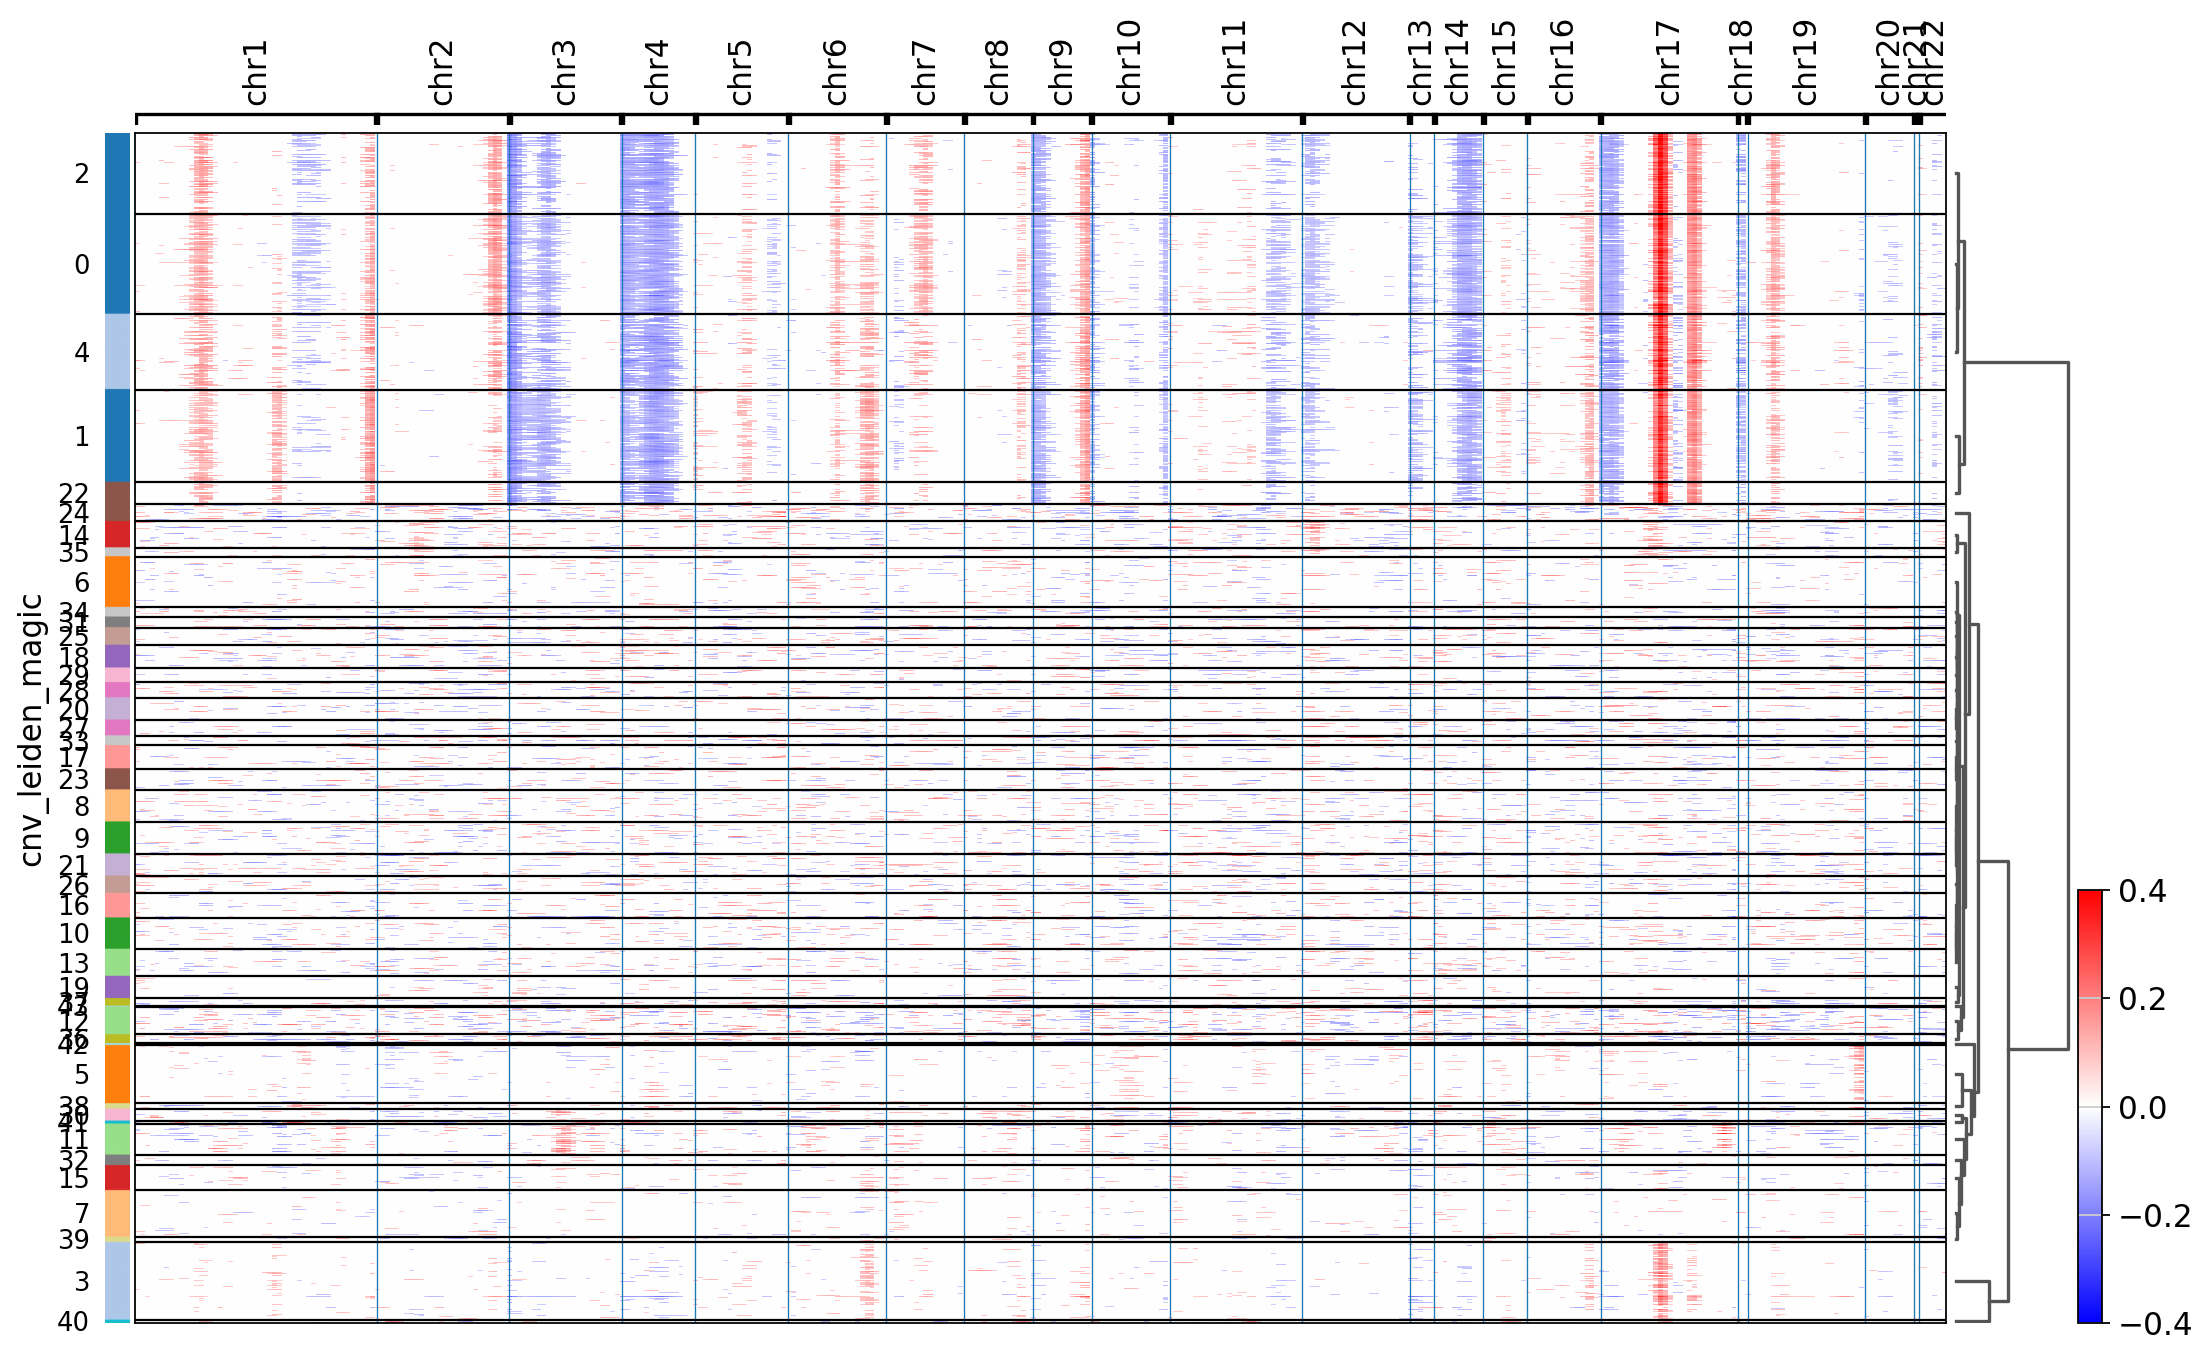

computing PCA
    with n_comps=50
    finished (0:00:00)
Storing dendrogram info using `.uns['dendrogram_cnv_leiden_smooth']`
categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


<Figure size 1280x1280 with 0 Axes>

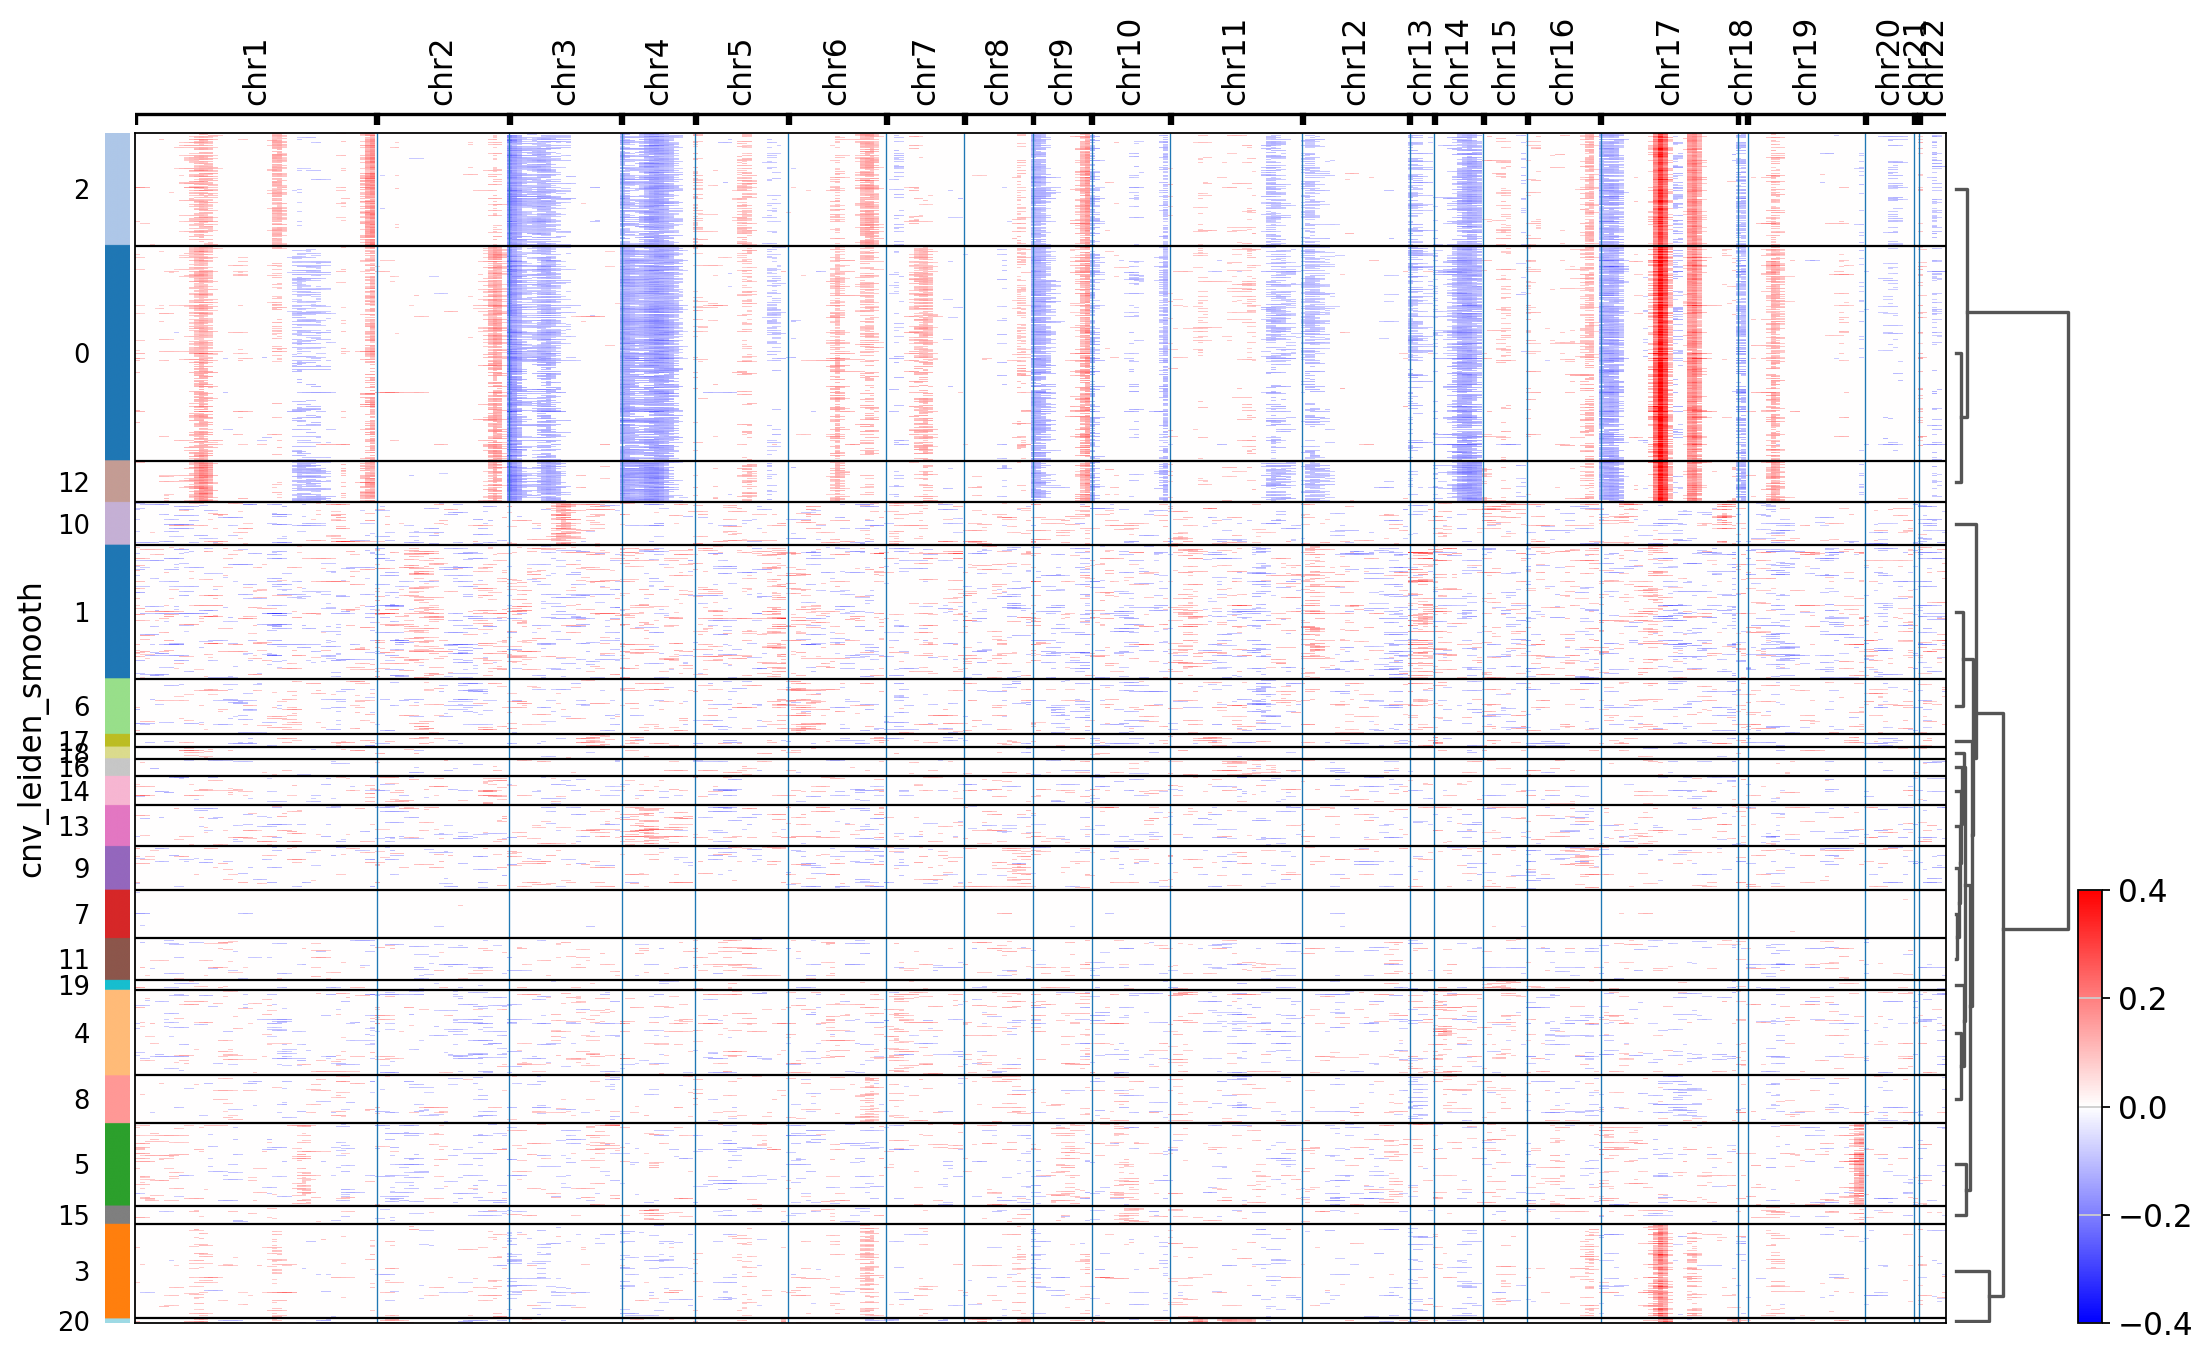

<Figure size 1280x1280 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt

def plot_cnv_heatmap_triptych(ad, title_prefix):
    # No ax/show passed to chromosome_heatmap to avoid the "multiple values for ax" error
    for m in METHODS:
        if f'gene_values_cnv_{m}' in ad.layers:
            ad.layers['gene_values_cnv'] = ad.layers[f'gene_values_cnv_{m}']
        cnv.pl.chromosome_heatmap(
            ad,
            dendrogram=True,
            groupby=f'cnv_leiden_{m}',
            vmax=0.4,
            vmin=-0.4,
        )
        plt.gcf().suptitle(f"{title_prefix} | {m}")

plot_cnv_heatmap_triptych(adata, "1105_BL")

## Annotate tumor CNV clusters per method


In [10]:
# Fill in tumor cluster IDs per method as needed
tumor_clusters = {
    'log_norm': {'0'},
    'magic': {'2', '0', '4', '1', '22'},
    'smooth': {'2', '0', '12'},
}

# Directory for per-method tumor mean CNV tables
tumor_csv_dir = '/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results/average_tumor_CNV_values_per_gene'
os.makedirs(tumor_csv_dir, exist_ok=True)

for m in METHODS:
    key = f'cnv_leiden_{m}'
    status_key = f'cnv_status_{m}'
    layer_name = f'gene_values_cnv_{m}'

    adata.obs[status_key] = adata.obs[key].astype(str).map(
        lambda x: 'tumor' if x in tumor_clusters.get(m, set()) else 'normal'
    )

    tumor_mask = adata.obs[status_key] == 'tumor'
    tumor_count = int(tumor_mask.sum())
    print(f"{m}: found {tumor_count} tumor cells")

    if tumor_count == 0:
        print(f"Skipping {m}: no tumor cells found")
        continue

    if layer_name not in adata.layers:
        print(f"Skipping {m}: layer {layer_name} not found")
        continue

    # Use the CNV values from the correct layer
    tumor_matrix = adata[tumor_mask].layers[layer_name]

    # Mean CNV per gene across tumor cells
    tumor_mean = tumor_matrix.mean(axis=0)

    # Handle sparse / matrix output
    if hasattr(tumor_mean, "A1"):
        tumor_mean = tumor_mean.A1
    else:
        tumor_mean = np.asarray(tumor_mean).reshape(-1)

    # Build output table
    out_df = adata.var.copy()

    if 'gene' not in out_df.columns:
        out_df['gene'] = adata.var_names

    out_df = out_df[['gene', 'chromosome', 'start', 'end']].copy()
    out_df['CNV_value'] = tumor_mean

    out_csv = os.path.join(tumor_csv_dir, f'1105_BL_tumor_mean_{m}.csv')
    out_df.to_csv(out_csv, index=False)

    print(f"Saved tumor mean CNV table ({m}) -> {out_csv}")

log_norm: found 5709 tumor cells
Saved tumor mean CNV table (log_norm) -> /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results/average_tumor_CNV_values_per_gene/1105_BL_tumor_mean_log_norm.csv
magic: found 6051 tumor cells
Saved tumor mean CNV table (magic) -> /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results/average_tumor_CNV_values_per_gene/1105_BL_tumor_mean_magic.csv
smooth: found 6030 tumor cells
Saved tumor mean CNV table (smooth) -> /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/results/average_tumor_CNV_values_per_gene/1105_BL_tumor_mean_smooth.csv


## Side-by-side spatial plots (lognorm, MAGIC, smooth)


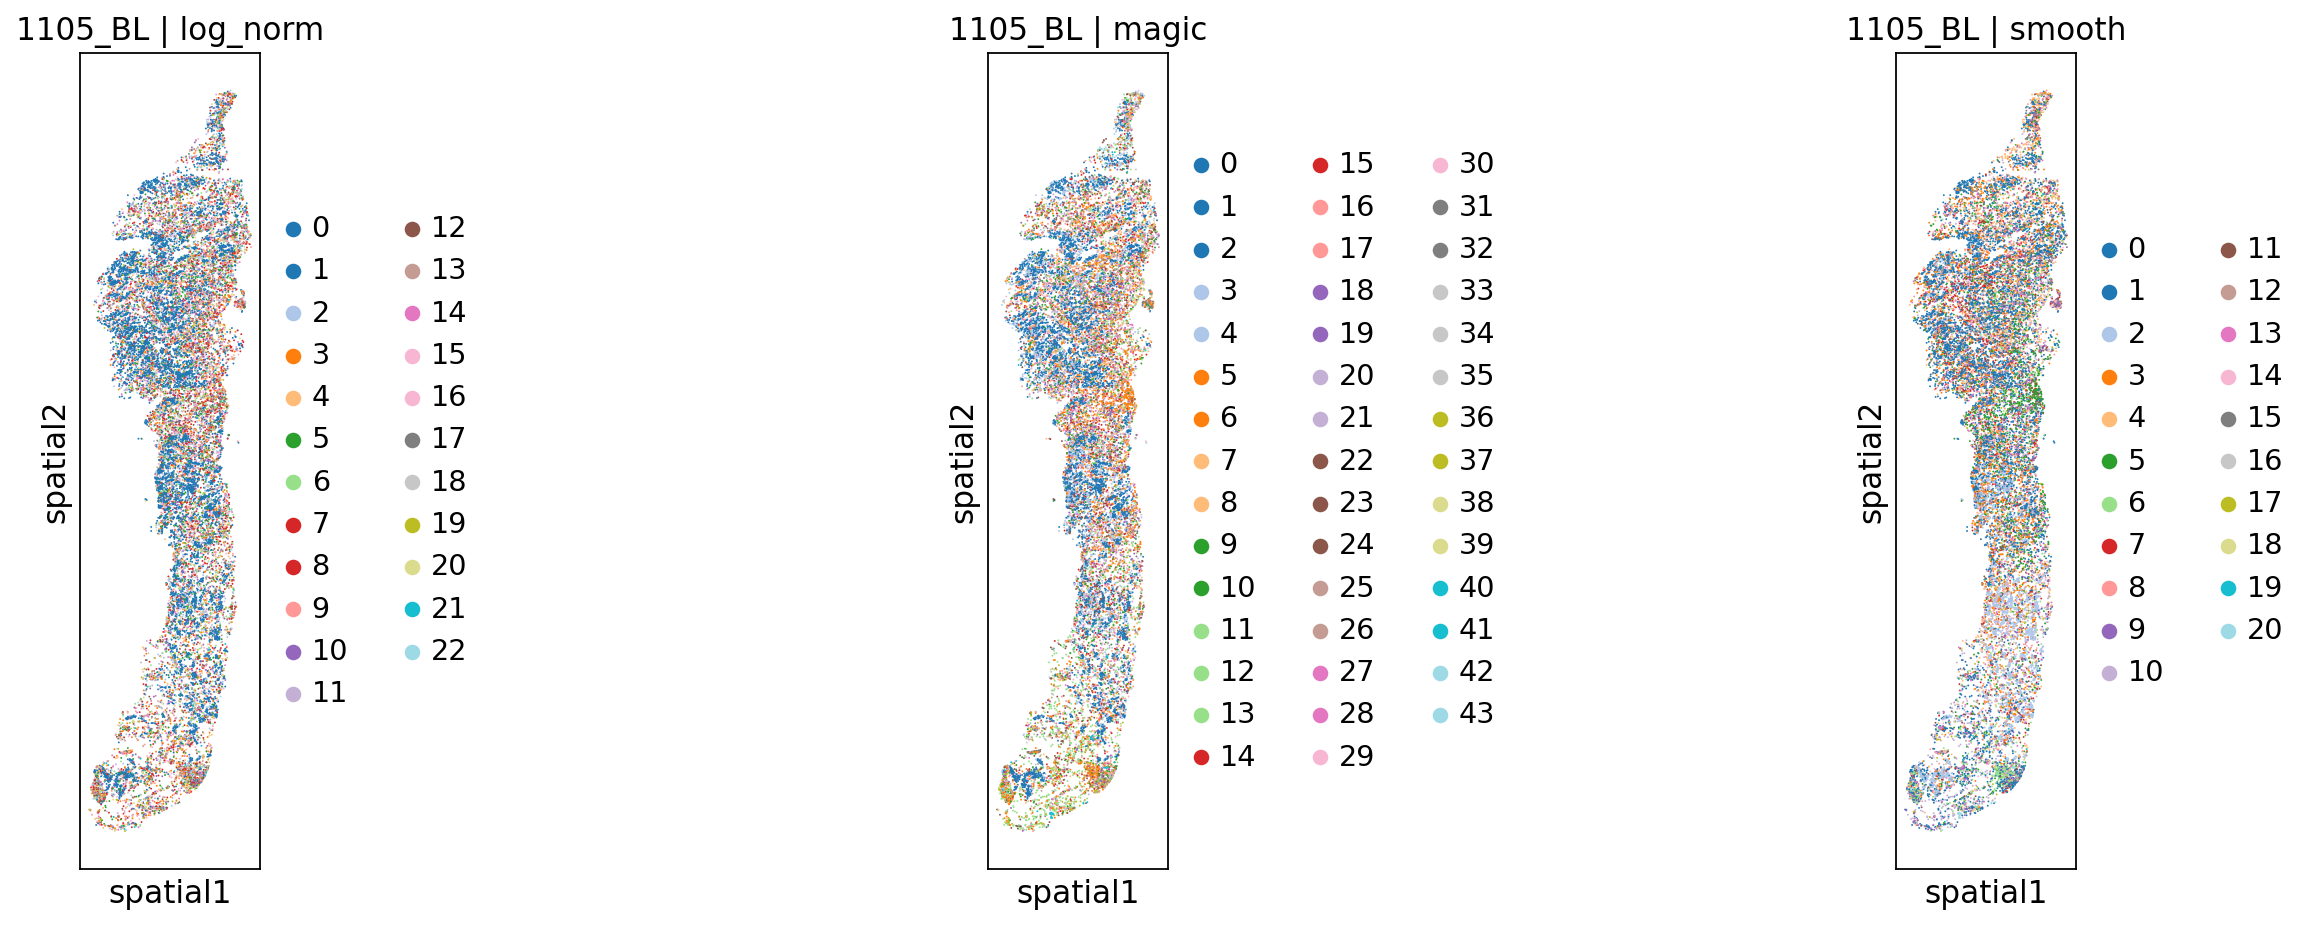

In [11]:
import matplotlib.pyplot as plt


def plot_spatial_triptych(ad, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, m in zip(axes, METHODS):
        sc.pl.spatial(
            ad,
            color=f'cnv_leiden_{m}',
            spot_size=15,
            ax=ax,
            show=False,
            title=f"{title_prefix} | {m}",
        )
    plt.tight_layout()


plot_spatial_triptych(adata, '1105_BL')

# Save figures


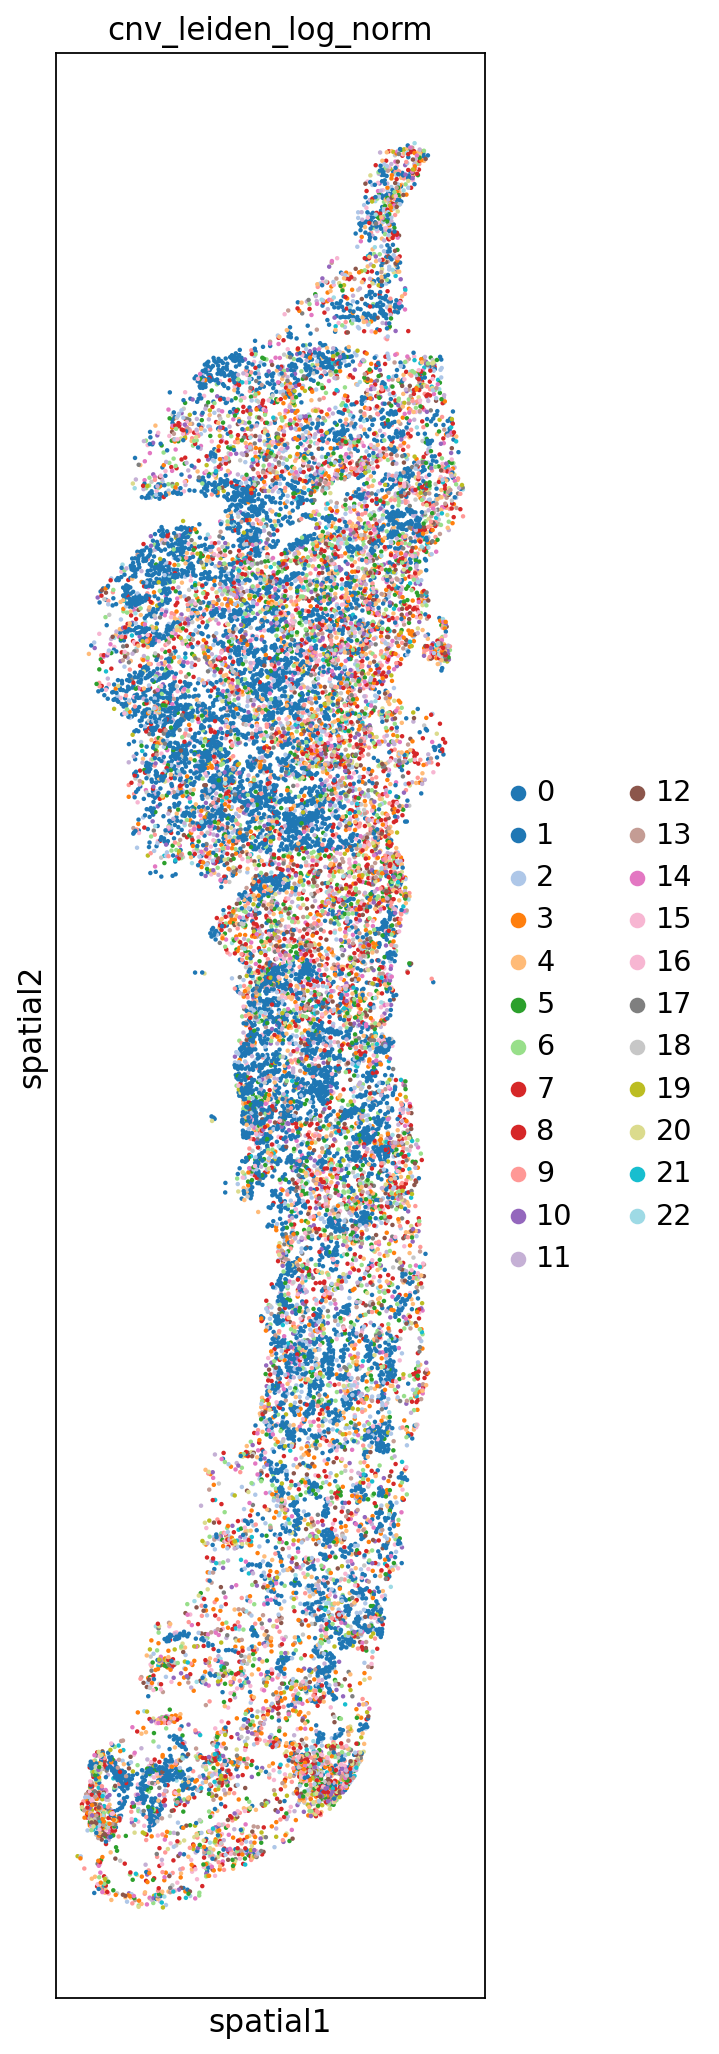

categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


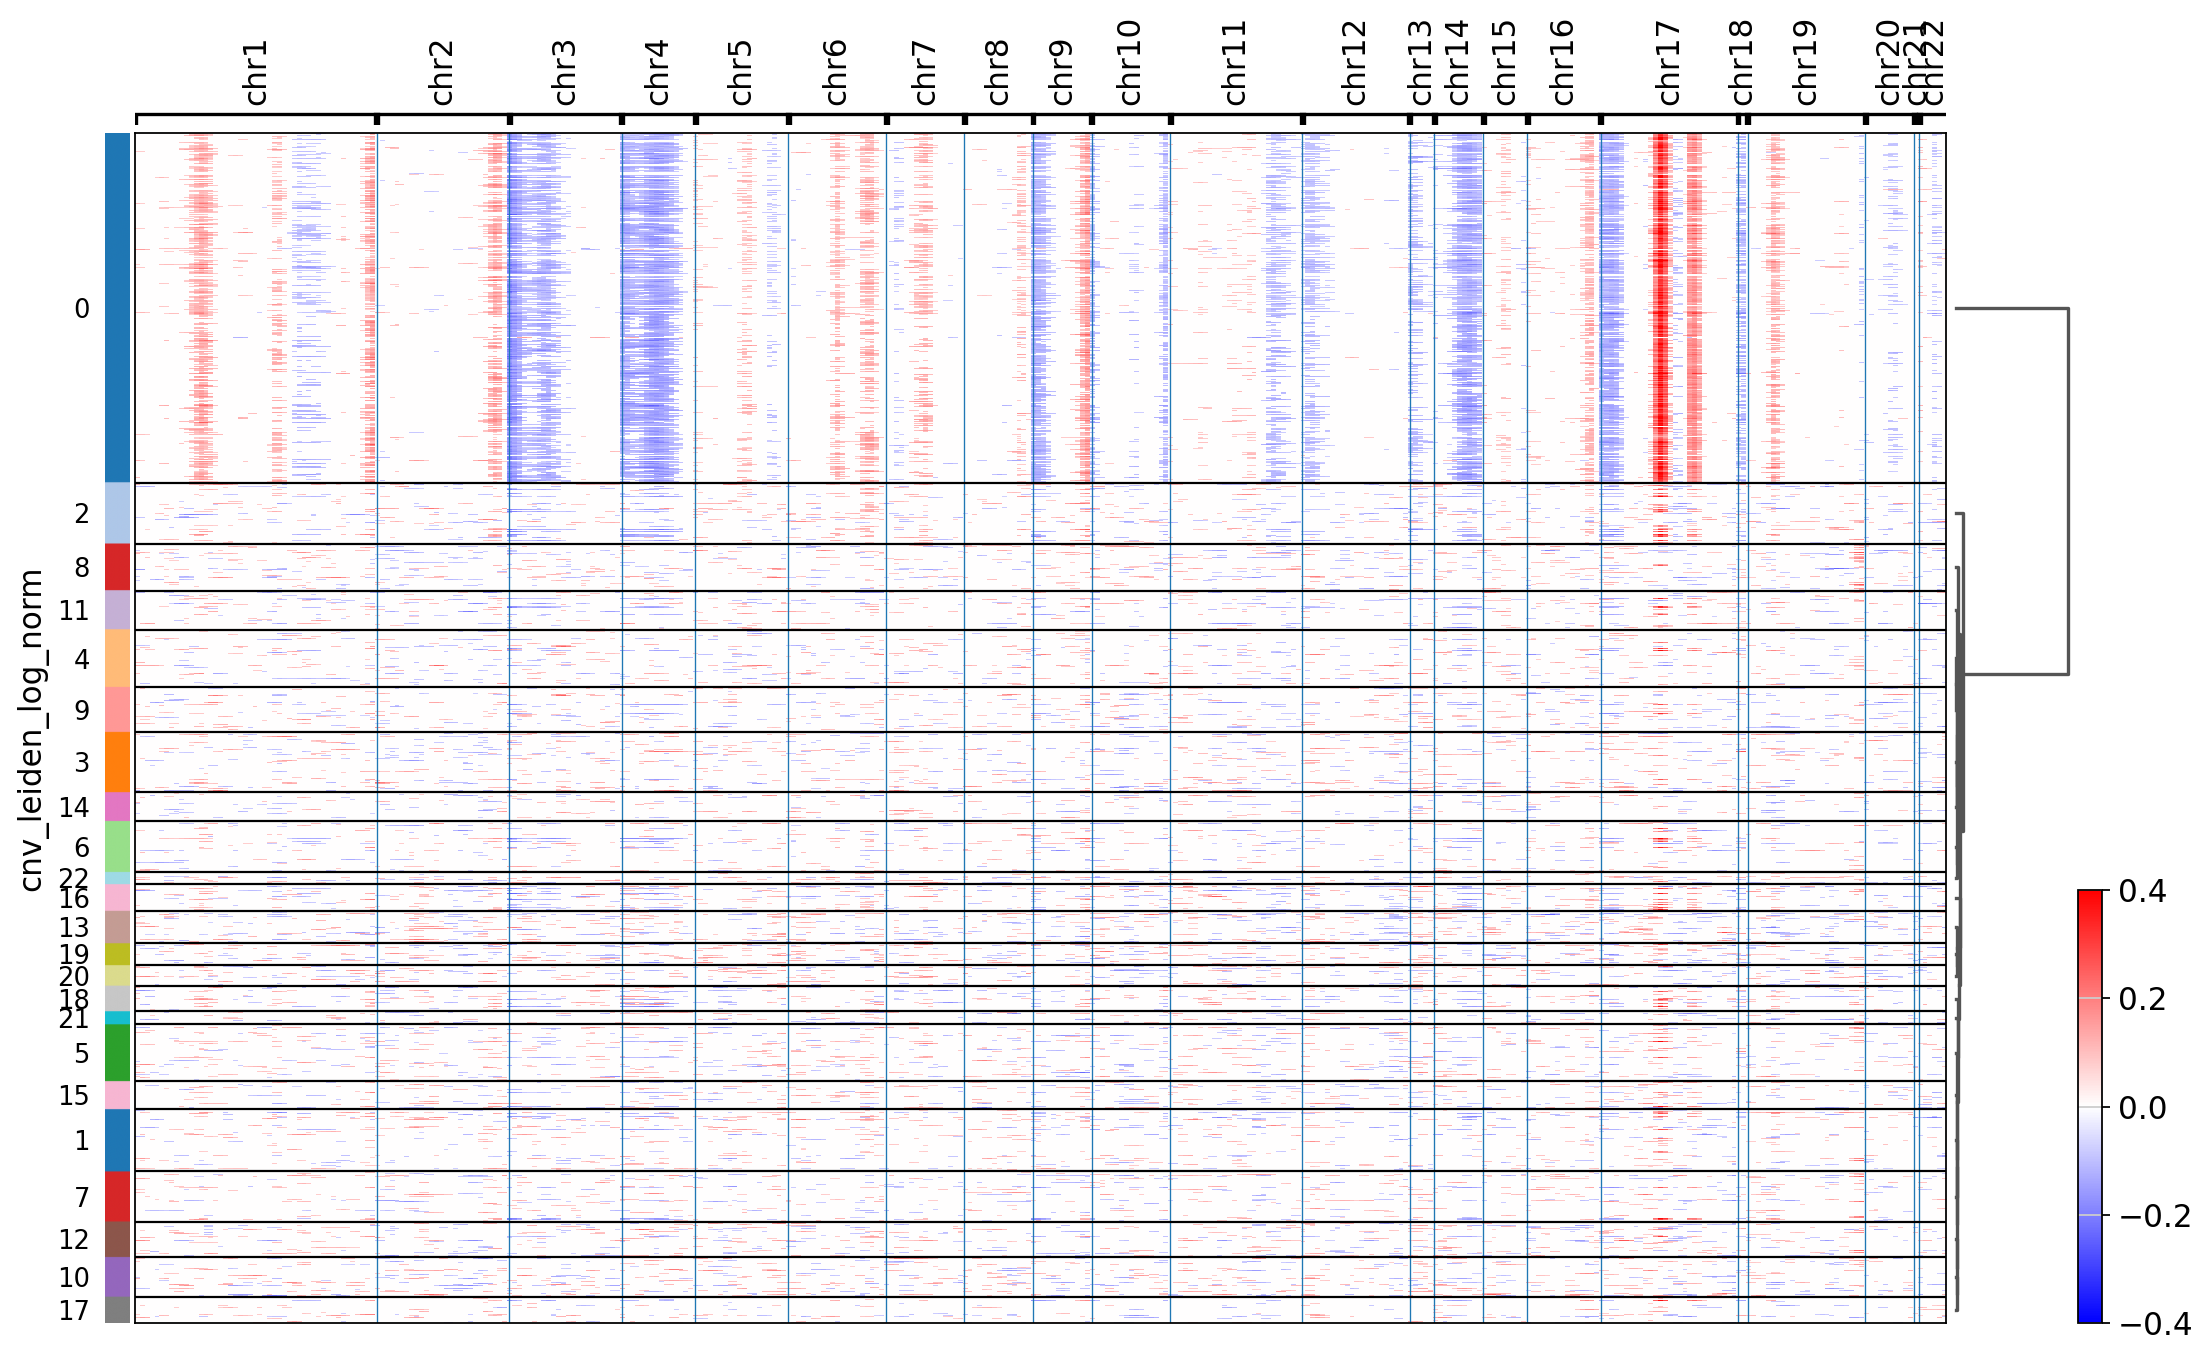

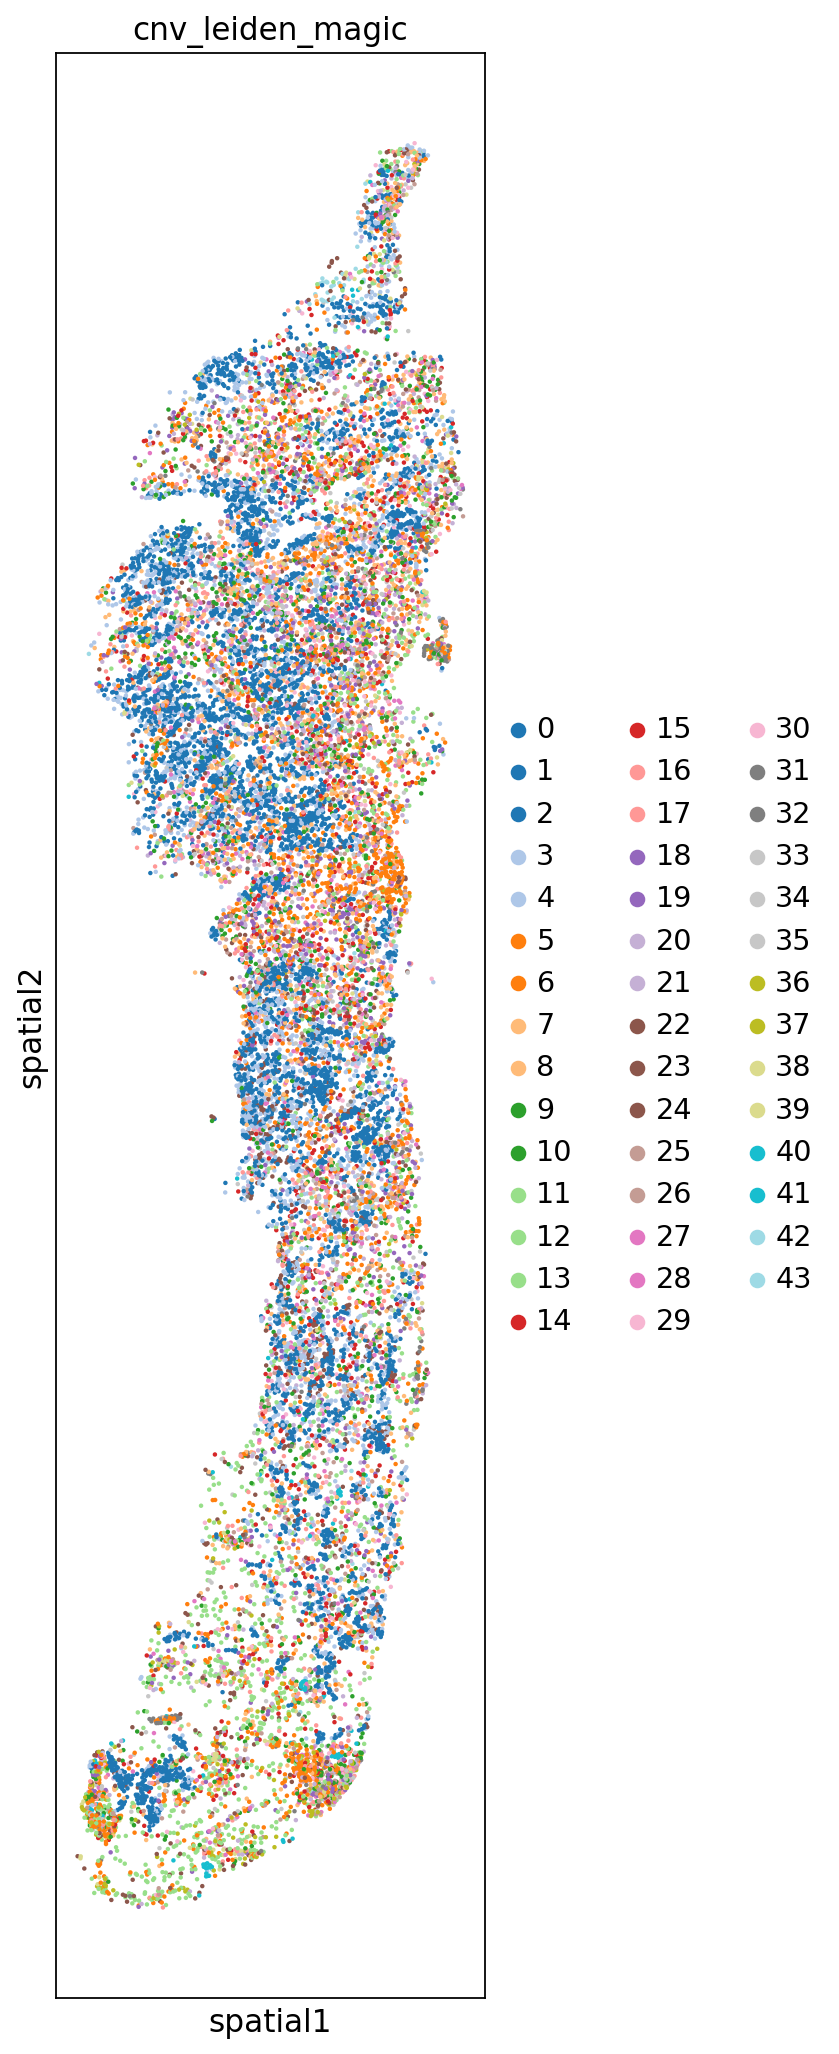

categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


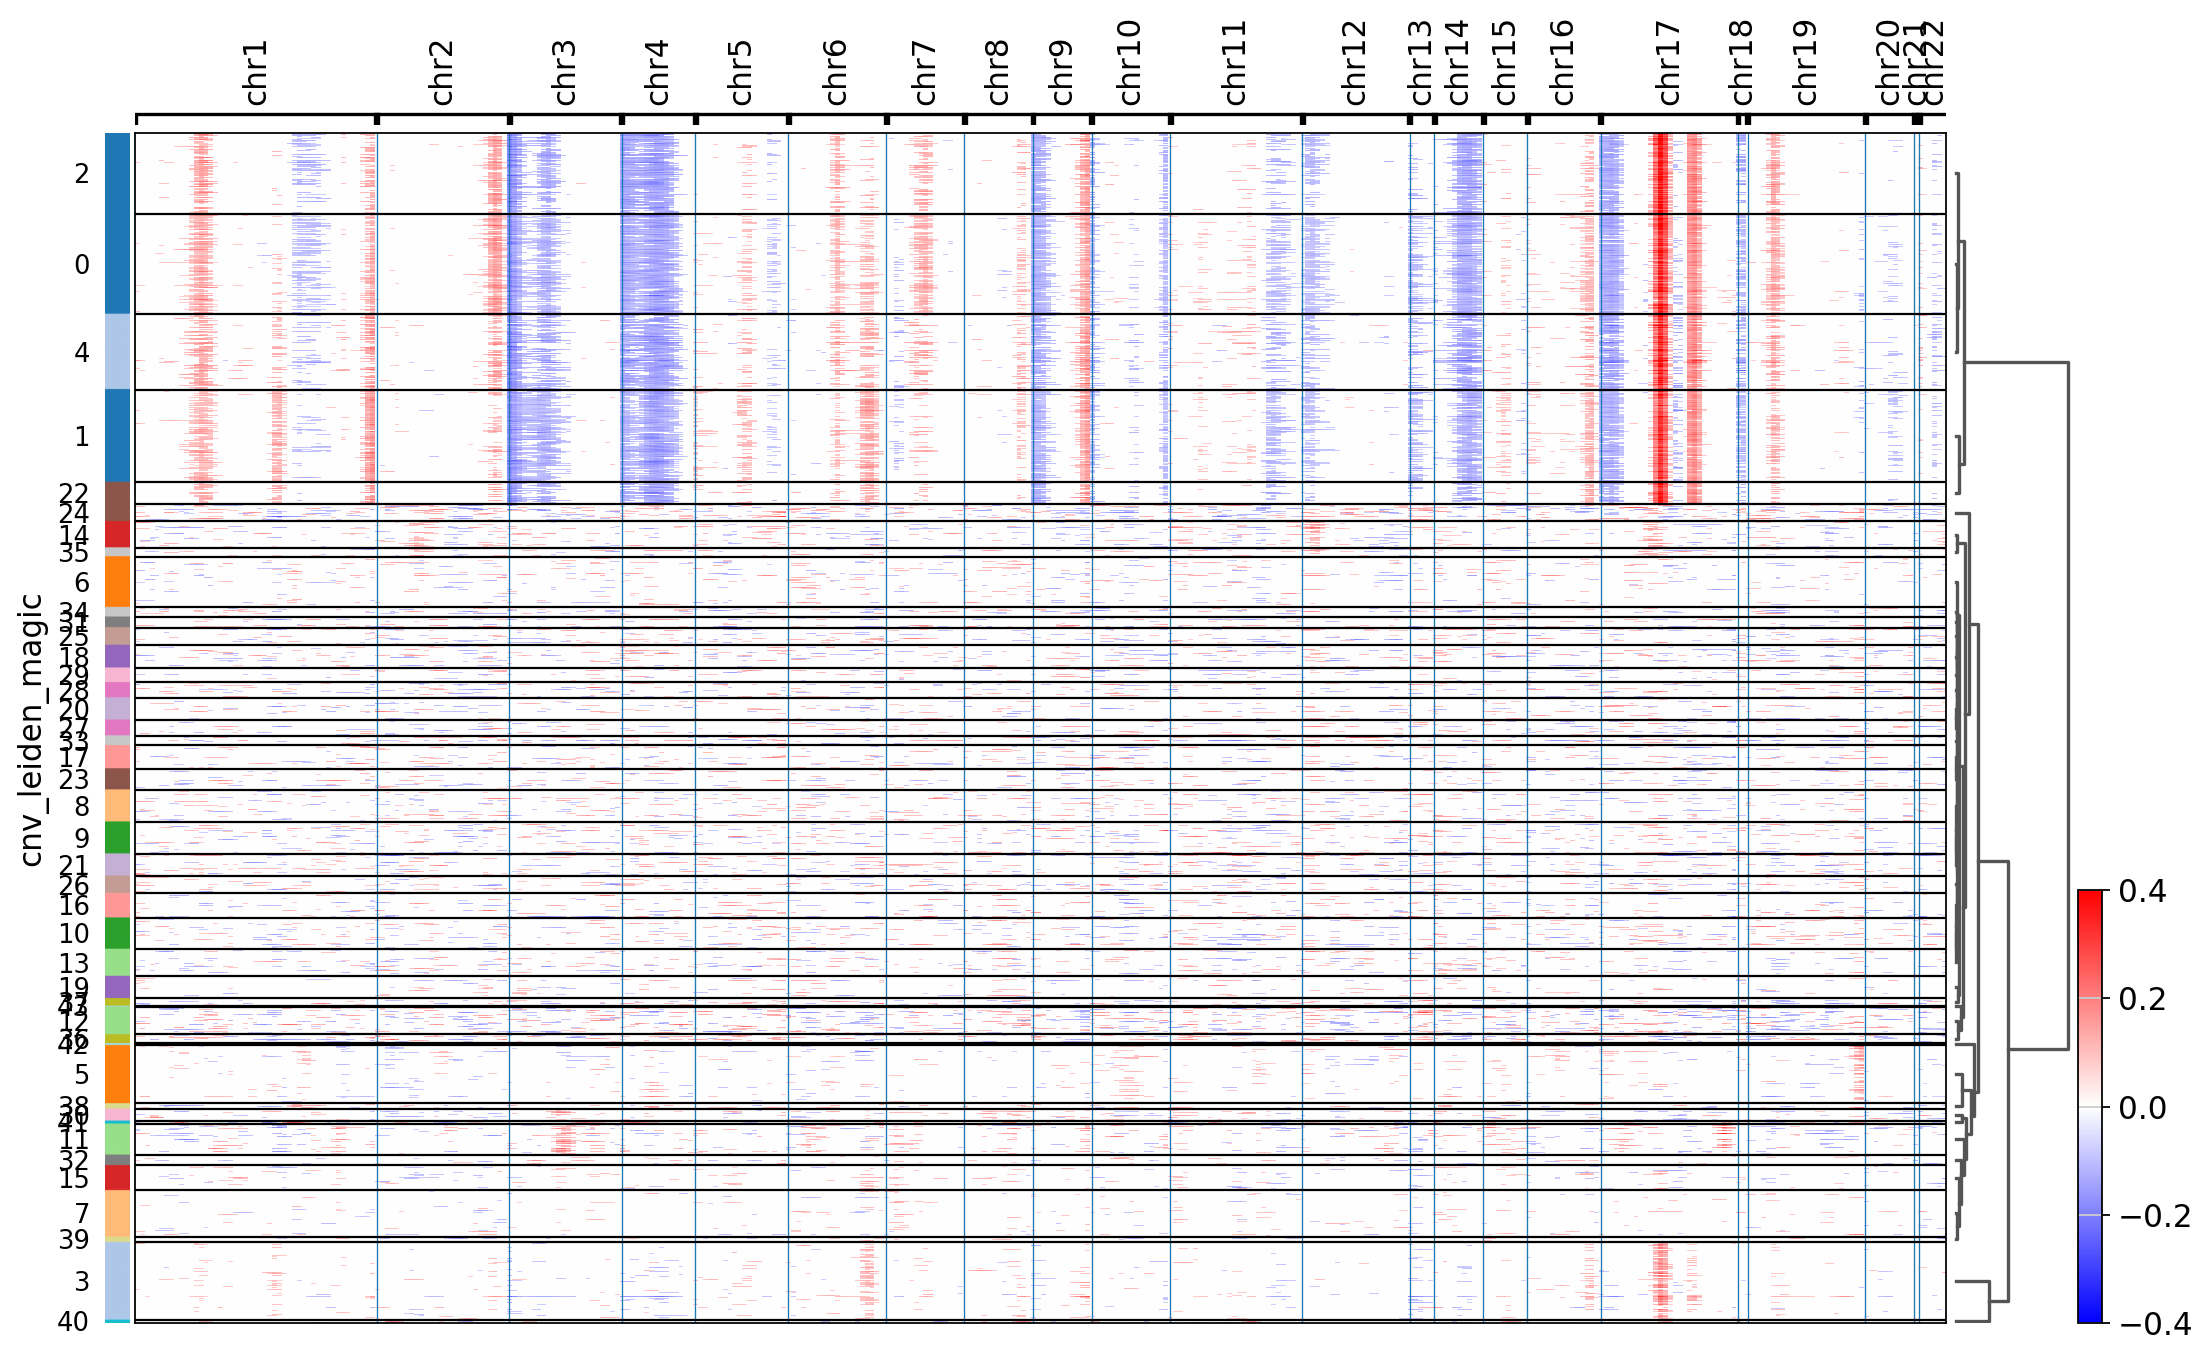

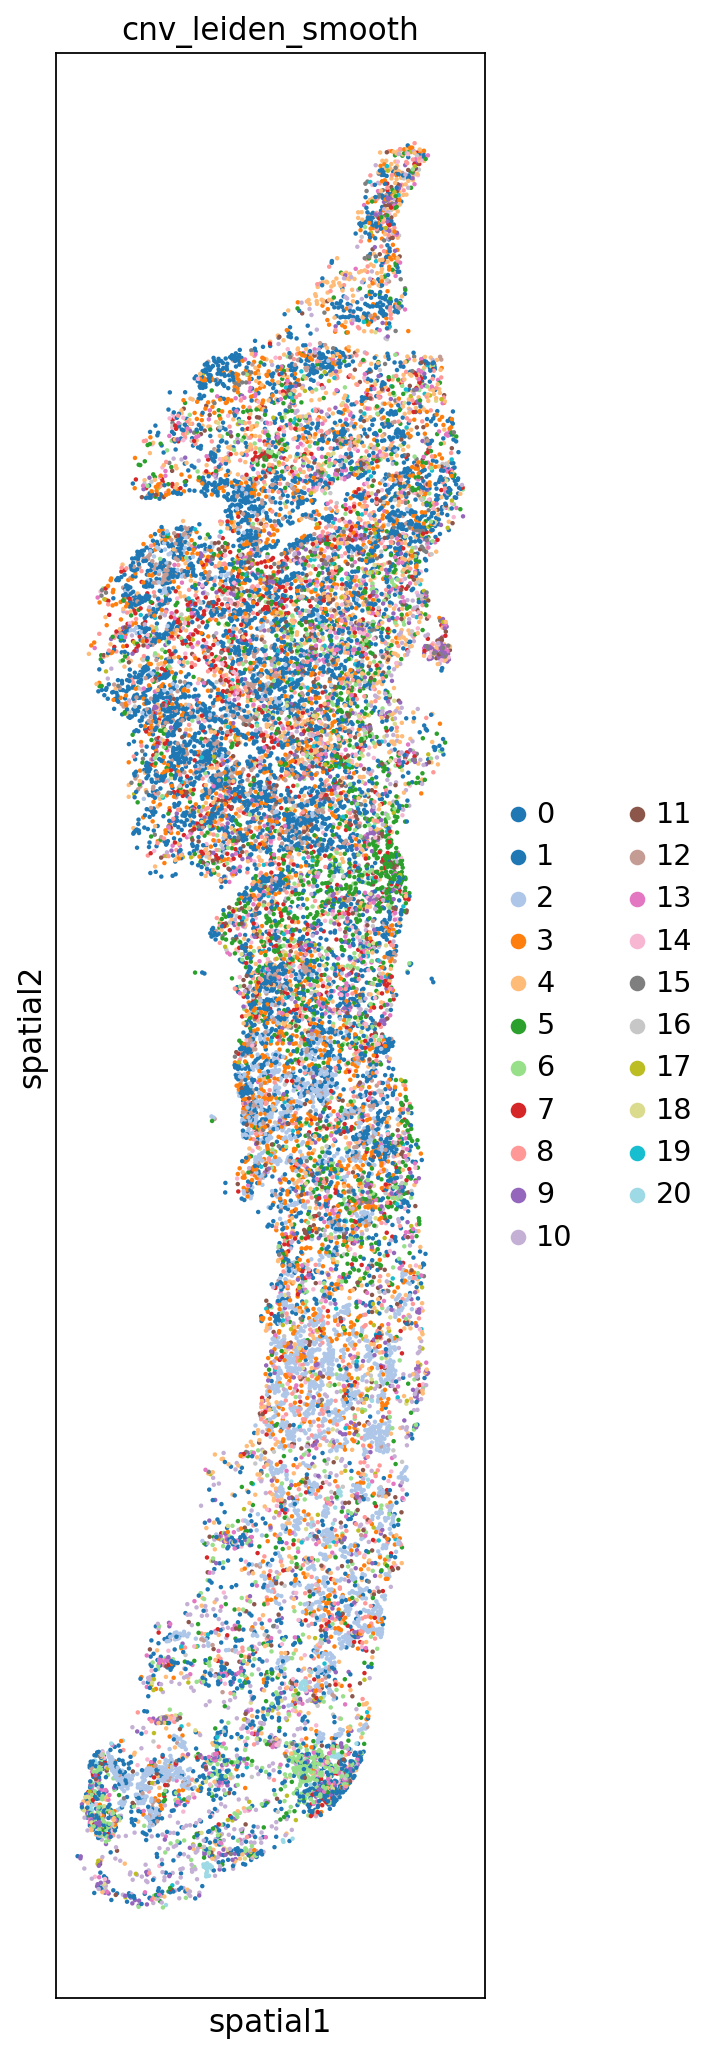

categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


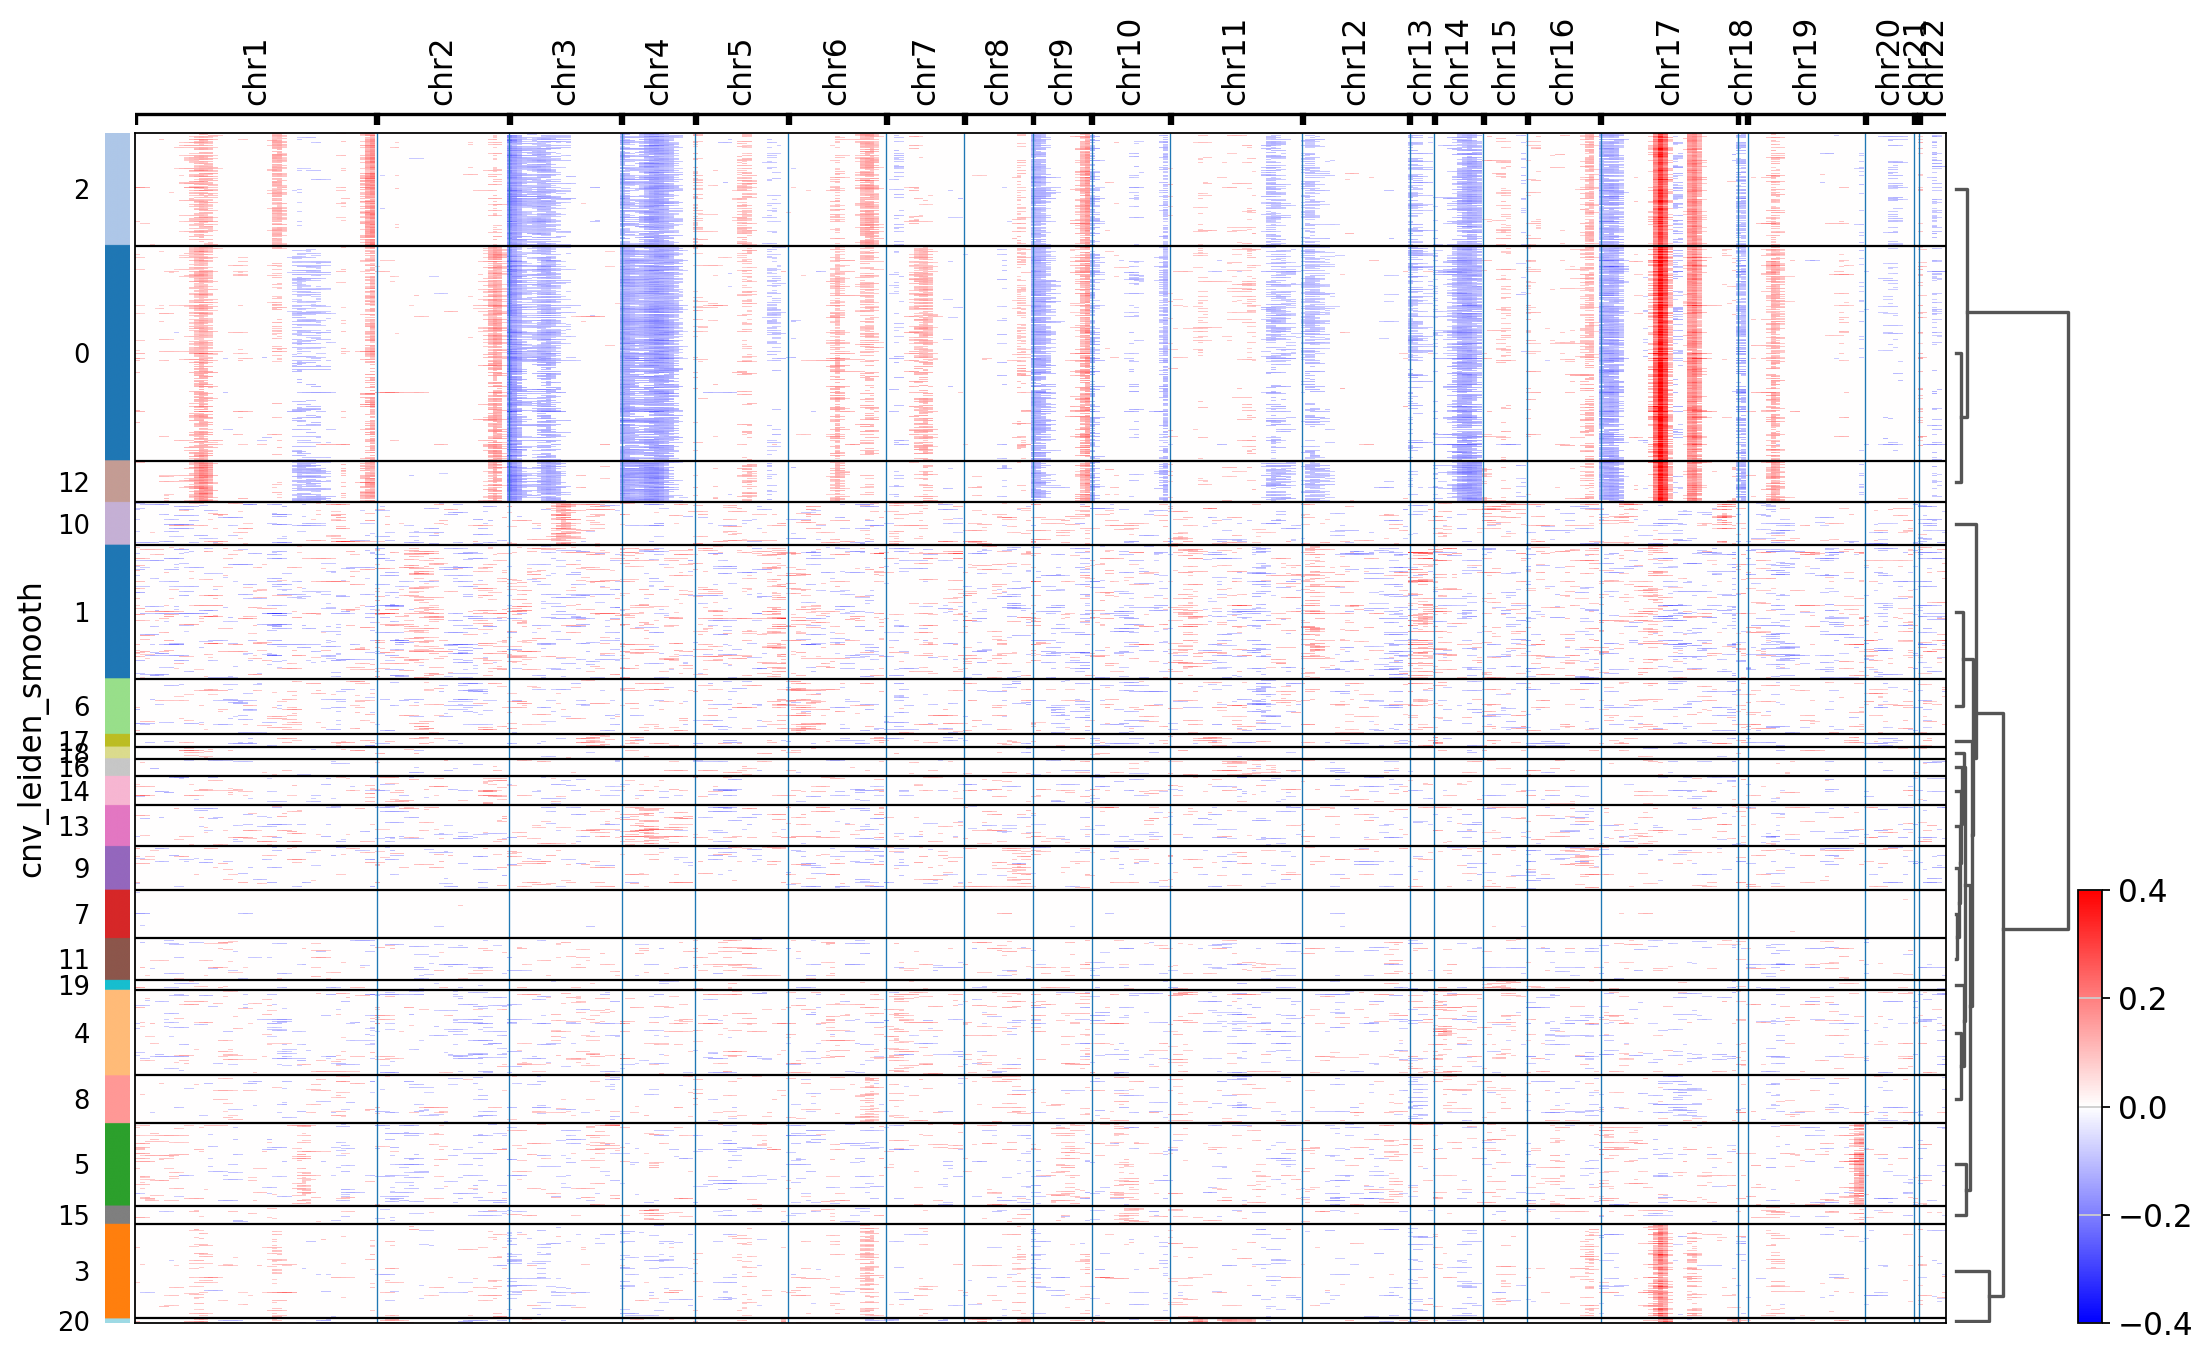

In [12]:
# Optional: save per-method spatial + heatmap figures
# Uncomment if you want to write files

for m in METHODS:
    sc.pl.spatial(
        adata,
        color=f'cnv_leiden_{m}',
        spot_size=15,
        save=f'_cnv_leiden_{m}_1105_BL.pdf',
    )
    cnv.pl.chromosome_heatmap(
        adata,
        dendrogram=True,
        groupby=f'cnv_leiden_{m}',
        vmax=.4,
        vmin=-.4,
        save=f'_cnv_leiden_{m}_1105_BL.pdf',
    )


# Save AnnData with all CNV clusterings


In [13]:
out_path = "/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/data/1105_BL_CNV_denoisings.h5ad"
adata.write(out_path, compression='gzip')
print('Wrote', out_path)

Wrote /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings/data/1105_BL_CNV_denoisings.h5ad
